# RelBench Regression Task Benchmarks with FK-Join Cardinality Profiles

This notebook demonstrates the **RelBench regression task benchmark dataset** with detailed FK-join cardinality profiles.

**What this artifact does:**
- Extracts relational schema metadata (table names, row counts, column types, PKs, FKs) from cached RelBench parquet files
- Computes per-edge FK-join cardinality distributions (min/p25/median/mean/p75/p90/p95/p99/max)
- Extracts train/val/test split statistics with target distributions
- Processes three RelBench regression tasks: `rel-f1/driver-position`, `rel-stack/post-votes`, `rel-amazon/item-ltv`

**Source:** [RelBench: A Benchmark for Deep Learning on Relational Databases (NeurIPS 2024)](https://arxiv.org/abs/2407.20060)

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/dataset_iter1_relbench_regres/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'])} dataset(s)")
print(f"Metadata keys: {list(data['metadata'].keys())}")

Loaded data with 1 dataset(s)
Metadata keys: ['description', 'source', 'paper', 'paper_url', 'num_tasks_requested', 'num_tasks_downloaded', 'blocked_tasks', 'tasks_metadata']


In [5]:
# ---------------------------------------------------------------------------
# Config — tunable parameters (start with minimum values)
# ---------------------------------------------------------------------------
MAX_EXAMPLES_DISPLAY = 5      # Number of example rows to display in tables
SAMPLE_FRAC = 0.05            # Mini dataset sampling fraction (original: 0.05)
MAX_PER_SPLIT = 5000          # Max examples per split (original: 5000)
N_BINS_HISTOGRAM = 10         # Number of bins for histograms

## 1. Dataset Overview and Schema Metadata

Extract and display the relational schema for each task: table names, row counts, column types, primary keys, and foreign key relationships.

In [6]:
# ---------------------------------------------------------------------------
# Extract schema metadata from the loaded data
# ---------------------------------------------------------------------------
tasks_metadata = data["metadata"]["tasks_metadata"]

for tm in tasks_metadata:
    ds_name = tm["dataset"]
    task_name = tm["task"]
    schema = tm["schema"]
    print(f"{'=' * 60}")
    print(f"Dataset: {ds_name} | Task: {task_name}")
    print(f"{'=' * 60}")

    table_rows = []
    for tbl_name, tbl_info in schema["tables"].items():
        fk_edges = tbl_info.get("fkey_col_to_pkey_table", {})
        fk_str = ", ".join(f"{k}->{v}" for k, v in fk_edges.items()) if fk_edges else "-"
        table_rows.append([
            tbl_name,
            f"{tbl_info['num_rows']:,}",
            tbl_info["num_columns"],
            tbl_info.get("pkey_col", "-"),
            fk_str,
        ])

    print(tabulate(
        table_rows,
        headers=["Table", "Rows", "Cols", "PKey", "FK Edges"],
        tablefmt="grid",
    ))
    print()

Dataset: rel-f1 | Task: driver-position
+-----------------------+--------+--------+------------------------+---------------------------------------------------------------+
| Table                 | Rows   |   Cols | PKey                   | FK Edges                                                      |
+=======================+========+========+========================+===============================================================+
| circuits              | 77     |      8 | circuitId              | -                                                             |
+-----------------------+--------+--------+------------------------+---------------------------------------------------------------+
| constructor_results   | 12,290 |      5 | constructorResultsId   | raceId->races, constructorId->constructors                    |
+-----------------------+--------+--------+------------------------+---------------------------------------------------------------+
| constructor_standings | 13,

## 2. FK-Join Cardinality Profiles

Each FK edge has a cardinality distribution: how many child rows reference each parent key. These profiles capture min, percentiles, mean, and max — critical for understanding join fan-out in GNN message passing.

In [7]:
# ---------------------------------------------------------------------------
# Display FK cardinality profiles
# ---------------------------------------------------------------------------
for tm in tasks_metadata:
    ds_name = tm["dataset"]
    fk_profiles = tm["fk_cardinality_profiles"]
    print(f"{'=' * 60}")
    print(f"FK Cardinality Profiles for {ds_name}")
    print(f"{'=' * 60}")

    profile_rows = []
    for p in fk_profiles:
        cs = p["cardinality_stats"]
        profile_rows.append([
            p["edge_type"],
            f"{p['total_fk_references']:,}",
            p["num_parents_with_children"],
            p["num_parents_without_children"],
            cs["min"],
            cs["p25"],
            cs["median"],
            f"{cs['mean']:.1f}",
            cs["p75"],
            cs["p95"],
            cs["max"],
        ])

    print(tabulate(
        profile_rows,
        headers=["Edge", "Total Refs", "Parents+", "Parents-",
                 "Min", "P25", "Med", "Mean", "P75", "P95", "Max"],
        tablefmt="grid",
    ))
    print()

FK Cardinality Profiles for rel-f1
+-----------------------------------------------------+--------------+------------+------------+-------+-------+-------+--------+-------+-------+-------+
| Edge                                                | Total Refs   |   Parents+ |   Parents- |   Min |   P25 |   Med |   Mean |   P75 |   P95 |   Max |
+=====================================================+==============+============+============+=======+=======+=======+========+=======+=======+=======+
| races.circuitId -> circuits                         | 1,101        |         77 |          0 |     1 |     2 |     8 |   14.3 |    20 |    44 |    73 |
+-----------------------------------------------------+--------------+------------+------------+-------+-------+-------+--------+-------+-------+-------+
| results.raceId -> races                             | 26,080       |       1091 |         10 |    10 |    20 |    22 |   23.9 |    26 |    33 |    55 |
+----------------------------------------

## 3. Task Split Statistics

Each RelBench task has train/val/test splits. We display row counts, unique entities, and target value distributions for the regression targets.

In [8]:
# ---------------------------------------------------------------------------
# Display task split statistics
# ---------------------------------------------------------------------------
for tm in tasks_metadata:
    ds_name = tm["dataset"]
    task_stats = tm["task_stats"]
    print(f"{'=' * 60}")
    print(f"Task: {ds_name}/{task_stats['task']}  (type: {task_stats['task_type']})")
    print(f"  Entity col: {task_stats['entity_col']}  |  Target col: {task_stats['target_col']}")
    print(f"  Entity table: {task_stats['entity_table']}  |  Timedelta: {task_stats['timedelta_days']} days")
    print(f"  Metrics: {task_stats['metrics']}")
    print(f"{'=' * 60}")

    split_rows = []
    for split_name, split_info in task_stats["splits"].items():
        if isinstance(split_info, dict) and "num_rows" in split_info:
            ts = split_info.get("target_stats", {})
            if isinstance(ts, dict):
                split_rows.append([
                    split_name,
                    f"{split_info['num_rows']:,}",
                    split_info.get("num_unique_entities", "?"),
                    f"{ts.get('mean', 0):.4f}",
                    f"{ts.get('std', 0):.4f}",
                    f"{ts.get('min', 0):.2f}",
                    f"{ts.get('median', 0):.2f}",
                    f"{ts.get('max', 0):.2f}",
                ])
            else:
                split_rows.append([
                    split_name,
                    f"{split_info['num_rows']:,}",
                    split_info.get("num_unique_entities", "?"),
                    ts, "-", "-", "-", "-",
                ])

    print(tabulate(
        split_rows,
        headers=["Split", "Rows", "Entities", "Mean", "Std", "Min", "Median", "Max"],
        tablefmt="grid",
    ))
    print()

Task: rel-f1/driver-position  (type: regression)
  Entity col: driverId  |  Target col: position
  Entity table: drivers  |  Timedelta: 60 days
  Metrics: ['mae', 'rmse', 'r2']
+---------+--------+------------+---------+--------+-------+----------+-------+
| Split   | Rows   |   Entities |    Mean |    Std |   Min |   Median |   Max |
+=========+========+============+=========+========+=======+==========+=======+
| train   | 7,453  |        771 | 13.9014 | 7.0257 |     1 |    13.33 |    39 |
+---------+--------+------------+---------+--------+-------+----------+-------+
| val     | 499    |         47 | 11.0832 | 4.6407 |     1 |    11.4  |    22 |
+---------+--------+------------+---------+--------+-------+----------+-------+
| test    | 760    |         56 | 11.9262 | 5.2138 |     1 |    12.18 |    24 |
+---------+--------+------------+---------+--------+-------+----------+-------+



## 4. Mini Dataset Statistics

Estimated row counts for a 5% subsample of each table, useful for prototyping lightweight GNN pipelines.

In [9]:
# ---------------------------------------------------------------------------
# Mini dataset statistics — estimated row counts for each table
# ---------------------------------------------------------------------------
for tm in tasks_metadata:
    ds_name = tm["dataset"]
    mini_stats = tm["mini_dataset_stats"]
    print(f"{'=' * 60}")
    print(f"Mini Dataset Stats for {ds_name} (sample_frac={SAMPLE_FRAC})")
    print(f"{'=' * 60}")

    mini_rows = []
    for tbl_name, info in mini_stats.items():
        ratio = info["estimated_mini_rows"] / info["original_rows"] * 100
        mini_rows.append([
            tbl_name,
            f"{info['original_rows']:,}",
            f"{info['estimated_mini_rows']:,}",
            f"{ratio:.1f}%",
        ])

    print(tabulate(
        mini_rows,
        headers=["Table", "Original Rows", "Mini Rows", "Ratio"],
        tablefmt="grid",
    ))
    print()

Mini Dataset Stats for rel-f1 (sample_frac=0.05)
+-----------------------+-----------------+-------------+---------+
| Table                 | Original Rows   | Mini Rows   | Ratio   |
+=======================+=================+=============+=========+
| circuits              | 77              | 77          | 100.0%  |
+-----------------------+-----------------+-------------+---------+
| constructor_results   | 12,290          | 614         | 5.0%    |
+-----------------------+-----------------+-------------+---------+
| constructor_standings | 13,051          | 652         | 5.0%    |
+-----------------------+-----------------+-------------+---------+
| constructors          | 211             | 100         | 47.4%   |
+-----------------------+-----------------+-------------+---------+
| drivers               | 857             | 100         | 11.7%   |
+-----------------------+-----------------+-------------+---------+
| qualifying            | 9,815           | 490         | 5.0%    |

## 5. Example Data Points

Each example joins entity features with task split targets. The `input` field is a JSON string of features, and `output` is the regression target value.

In [10]:
# ---------------------------------------------------------------------------
# Parse and display example data points
# ---------------------------------------------------------------------------
fold_names = {0: "train", 1: "val", 2: "test"}

for ds_info in data["datasets"]:
    ds_name = ds_info["dataset"]
    examples = ds_info["examples"]
    print(f"{'=' * 60}")
    print(f"Examples for {ds_name}: {len(examples)} total")
    print(f"{'=' * 60}")

    # Parse input JSON strings into feature dicts
    parsed_examples = []
    for ex in examples[:MAX_EXAMPLES_DISPLAY]:
        features = json.loads(ex["input"])
        parsed_examples.append({
            "fold": fold_names.get(ex["metadata_fold"], ex["metadata_fold"]),
            "target": ex["output"],
            "entity_id": ex["metadata_row_index"],
            **{k: v for k, v in features.items()
               if k not in [ex["metadata_entity_col"]]},
        })

    df_examples = pd.DataFrame(parsed_examples)
    print(df_examples.to_string(index=False, max_colwidth=30))
    print()

Examples for rel-f1/driver-position: 30 total
 fold target  entity_id                date driverRef code forename surname                 dob nationality
train    1.0        579 1955-07-23T00:00:00    fangio   \N     Juan  Fangio 1911-06-24T00:00:00   Argentine
train    1.0        101 1989-03-26T00:00:00     senna   \N   Ayrton   Senna 1960-03-21T00:00:00   Brazilian
train    1.0        327 1969-01-10T00:00:00   stewart   \N   Jackie Stewart 1939-06-11T00:00:00     British
train    1.0        181 1977-01-28T00:00:00     lauda   \N     Niki   Lauda 1949-02-22T00:00:00    Austrian
train    1.0        766 1951-04-15T00:00:00   wallard   \N      Lee Wallard 1910-09-07T00:00:00    American



## 6. Visualization

**Top:** FK-join cardinality percentile profiles for each edge type (log scale).
**Bottom:** Distribution of regression target values across train/val/test folds.

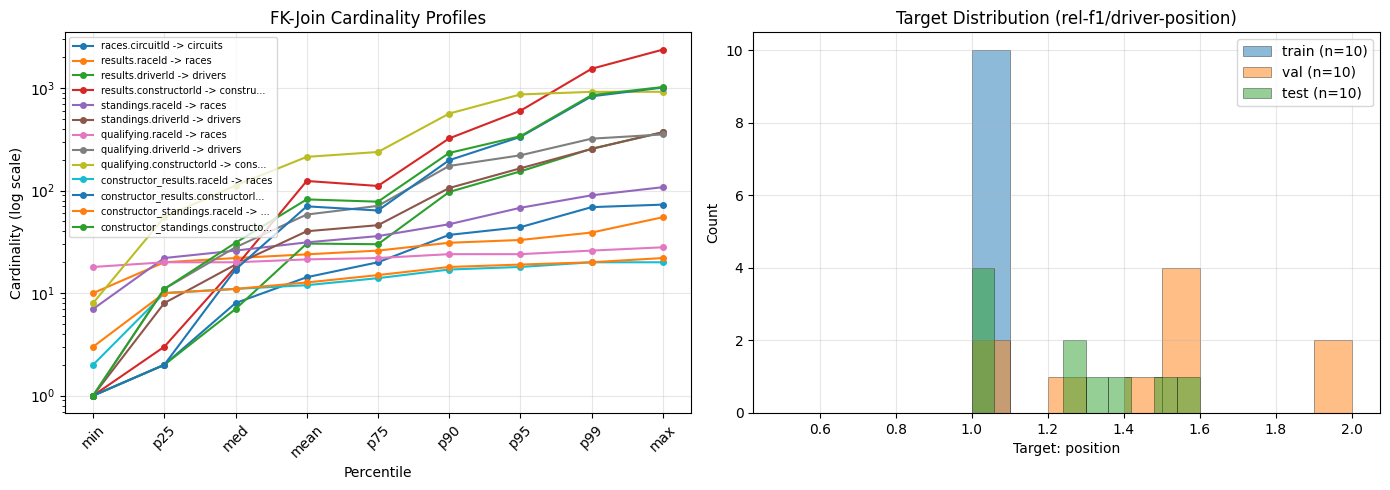

Saved demo_visualization.png


In [11]:
# ---------------------------------------------------------------------------
# Visualization: FK cardinality profiles + target distributions
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: FK cardinality percentile profiles ---
ax1 = axes[0]
percentile_keys = ["min", "p25", "median", "mean", "p75", "p90", "p95", "p99", "max"]
x_labels = ["min", "p25", "med", "mean", "p75", "p90", "p95", "p99", "max"]

for tm in tasks_metadata:
    for p in tm["fk_cardinality_profiles"]:
        cs = p["cardinality_stats"]
        values = [cs[k] for k in percentile_keys]
        label = p["edge_type"]
        if len(label) > 35:
            label = label[:32] + "..."
        ax1.plot(x_labels, values, marker="o", markersize=4, label=label)

ax1.set_yscale("log")
ax1.set_ylabel("Cardinality (log scale)")
ax1.set_xlabel("Percentile")
ax1.set_title("FK-Join Cardinality Profiles")
ax1.legend(fontsize=7, loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis="x", rotation=45)

# --- Plot 2: Target value distribution from examples ---
ax2 = axes[1]
for ds_info in data["datasets"]:
    examples = ds_info["examples"]
    target_vals = []
    fold_labels = []
    for ex in examples:
        if ex["output"] != "masked":
            target_vals.append(float(ex["output"]))
            fold_labels.append(fold_names.get(ex["metadata_fold"], "?"))

    if target_vals:
        df_targets = pd.DataFrame({"target": target_vals, "fold": fold_labels})
        for fold_name in ["train", "val", "test"]:
            fold_data = df_targets[df_targets["fold"] == fold_name]["target"]
            if len(fold_data) > 0:
                ax2.hist(fold_data, bins=N_BINS_HISTOGRAM, alpha=0.5,
                         label=f"{fold_name} (n={len(fold_data)})", edgecolor="black",
                         linewidth=0.5)

target_col = tasks_metadata[0]["task_stats"]["target_col"]
ax2.set_xlabel(f"Target: {target_col}")
ax2.set_ylabel("Count")
ax2.set_title(f"Target Distribution ({data['datasets'][0]['dataset']})")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("demo_visualization.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved demo_visualization.png")